In [1]:
from importlib import metadata
import subprocess
import sys

required_versions = {
    "orthojax": "0.1.5",
    "diffrax": "0.7.2",
}
packages_to_install = []
for package, required_version in required_versions.items():
    try:
        installed_version = metadata.version(package)
    except metadata.PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        packages_to_install.append(f"{package}=={required_version}")

if packages_to_install:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages_to_install]
    )

In [2]:
# BOOK_FIGURE_STYLE_CELL
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import orthojax as ojax

from diffrax import ODETerm, PIDController, SaveAt, Tsit5, diffeqsolve

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

FIGURE_SIZES = {
    "full_tall": (7.35, 5.50),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "purple": "#8F63B8",
    "gray": "#7F7F7F",
}

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7,
        "legend.frameon": False,
        "lines.linewidth": 1.5,
        "lines.markersize": 3.5,
    }
)


def finalize_axes(axes):
    for ax in np.atleast_1d(axes).ravel():
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)


def label_panels(axes):
    for index, ax in enumerate(np.atleast_1d(axes).ravel()):
        ax.text(
            -0.14,
            1.08,
            f"({chr(97 + index)})",
            transform=ax.transAxes,
            fontsize=9,
            fontweight="bold",
            ha="left",
            va="top",
        )

# Polynomial Chaos for a Scalar ODE


The preceding sections constructed orthonormal polynomials for a scalar random input. We now allow the coefficients of such an expansion to evolve in time. This converts an ordinary differential equation with an uncertain parameter into a deterministic system for the polynomial-chaos coefficients.

Let $\Xi$ have probability law $\mu$ on $I\subseteq\mathbb{R}$. For each input value $\xi\in I$, consider the scalar initial-value problem

$$
\frac{\partial x}{\partial t}(t;\xi)
=f(t,x(t;\xi);\xi),
\qquad
x(0;\xi)=x_{\mathrm{init}}(\xi).
$$

Assume that this problem has a unique solution on the time interval of interest and that $x(t;\cdot)$ and its time derivative belong to $L^2(\mu)$. Let $\{\phi_k\}_{k\geq0}$ be an orthonormal polynomial system for $\mu$, with $\phi_0=1$.

For a nonnegative polynomial degree $p$, approximate the solution by

$$
x_p(t;\xi)=\sum_{j=0}^{p}c_j(t)\phi_j(\xi).
$$

Define the residual

$$
R_p(t;\xi)
=\frac{\partial x_p}{\partial t}(t;\xi)
-f(t,x_p(t;\xi);\xi).
$$

The stochastic Galerkin condition requires the residual to be orthogonal to every retained basis function:

$$
\langle R_p(t;\cdot),\phi_i\rangle_\mu=0,
\qquad i=0,\ldots,p.
$$

Orthonormality then gives the finite coefficient system

$$
\dot c_i(t)
=\left\langle
f\!\left(t,\sum_{j=0}^{p}c_j(t)\phi_j(\cdot);\cdot\right),
\phi_i
\right\rangle_\mu,
\qquad i=0,\ldots,p,
$$

with projected initial conditions

$$
c_i(0)=\langle x_{\mathrm{init}},\phi_i\rangle_\mu.
$$

This intrusive construction is the stochastic Galerkin form of polynomial chaos {cite:p}`xiu2002wiener`.

## Quadrature and moments

The coefficient equations contain expectations with respect to $\mu$. Given quadrature nodes and weights $\{(\xi_q,w_q)\}_{q=1}^{Q}$, we approximate them by

$$
\dot c_i(t)
\approx
\sum_{q=1}^{Q}w_q
f\!\left(t,\sum_{j=0}^{p}c_j(t)\phi_j(\xi_q);\xi_q\right)
\phi_i(\xi_q).
$$

Let $X_t^{(p)}=x_p(t;\Xi)$. Because $\phi_0=1$, its mean and variance are

$$
\mathbb{E}[X_t^{(p)}]=c_0(t),
\qquad
\operatorname{Var}[X_t^{(p)}]
=\sum_{i=1}^{p}c_i(t)^2.
$$

These are the moments of the truncated Galerkin approximation. Approximating the moments of the exact solution also requires convergence with respect to the polynomial degree, the quadrature rule, and the numerical integration of the coefficient system.

## Example: an uncertain decay rate

Consider

$$
\frac{\partial x}{\partial t}(t;\xi)
=-(\lambda_0+\lambda_1\xi)x(t;\xi),
\qquad
x(0;\xi)=1,
$$

where $\Xi\sim\mathcal{U}[-1,1]$, $\lambda_0=0.5$, and $\lambda_1=0.1$. The exact solution is

$$
x(t;\xi)=\exp[-(\lambda_0+\lambda_1\xi)t].
$$

For the normalized Legendre basis, the Galerkin equations reduce to

$$
\dot c_i(t)
=-\sum_{j=0}^{p}c_j(t)
\left(\lambda_0\delta_{ij}
+\lambda_1\mathbb{E}[\Xi\phi_j(\Xi)\phi_i(\Xi)]\right),
$$

where $\delta_{ij}$ is the Kronecker delta. We construct the basis with Orthojax {cite:p}`bilionis2024orthojax` and use a sufficiently fine quadrature rule to check both its Gram matrix and the initial projection.

In [3]:
degree = 5
poly = ojax.make_legendre_polynomial(degree, ncap=512)
quadrature_nodes, quadrature_weights = poly.quad
basis_at_nodes = poly(quadrature_nodes)

gram_matrix = jnp.einsum(
    "qi,qj,q->ij",
    basis_at_nodes,
    basis_at_nodes,
    quadrature_weights,
)
projected_initial = jnp.einsum(
    "q,qj,q->j",
    jnp.ones_like(quadrature_nodes),
    basis_at_nodes,
    quadrature_weights,
)
exact_initial = jnp.zeros(degree + 1).at[0].set(1.0)

gram_error = float(jnp.max(jnp.abs(gram_matrix - jnp.eye(degree + 1))))
initial_projection_error = float(jnp.max(jnp.abs(projected_initial - exact_initial)))

print(f"Maximum Gram-matrix error:      {gram_error:.3e}")
print(f"Maximum initial-projection error: {initial_projection_error:.3e}")

assert gram_error < 3e-6
assert initial_projection_error < 1e-6

Maximum Gram-matrix error:      2.228e-06
Maximum initial-projection error: 6.495e-07


The exact initial coefficient vector is $(1,0,\ldots,0)$ because $x_{\mathrm{init}}=\phi_0=1$. We use this vector exactly. For a general initial condition, the same quadrature projection used above supplies the starting coefficients.

The following function evaluates the truncated state at the quadrature nodes and projects the vector field back onto the retained basis. The resulting system is integrated with Diffrax {cite:p}`kidger2021on`.

In [4]:
def make_scalar_galerkin_rhs(poly, vector_field):
    nodes, weights = poly.quad
    basis = poly(nodes)

    def coefficient_rhs(t, coefficients, parameters):
        state_at_nodes = basis @ coefficients
        field_at_nodes = vector_field(t, state_at_nodes, nodes, parameters)
        return jnp.einsum("q,qi,q->i", field_at_nodes, basis, weights)

    return coefficient_rhs


def decay_vector_field(t, state, xi, parameters):
    lambda_0, lambda_1 = parameters
    return -(lambda_0 + lambda_1 * xi) * state


parameters = jnp.array([0.5, 0.1])
coefficient_rhs = make_scalar_galerkin_rhs(poly, decay_vector_field)

In [5]:
times = jnp.linspace(0.0, 10.0, 401)
solution = diffeqsolve(
    ODETerm(coefficient_rhs),
    Tsit5(),
    t0=times[0],
    t1=times[-1],
    dt0=0.05,
    y0=exact_initial,
    args=parameters,
    saveat=SaveAt(ts=times),
    stepsize_controller=PIDController(rtol=1e-10, atol=1e-12),
    max_steps=100_000,
)

pc_mean = np.asarray(solution.ys[:, 0])
pc_variance = np.sum(np.asarray(solution.ys[:, 1:]) ** 2, axis=1)

## Comparison with the exact moments

Define the continuous function

$$
\operatorname{sinhc}(z)=
\begin{cases}
\sinh(z)/z, & z\neq0,\\
1, & z=0.
\end{cases}
$$

Integration over the uniform input gives

$$
\mathbb{E}[X_t]
=e^{-\lambda_0t}\operatorname{sinhc}(\lambda_1t),
$$

and

$$
\mathbb{E}[X_t^2]
=e^{-2\lambda_0t}\operatorname{sinhc}(2\lambda_1t).
$$

The exact variance is $\mathbb{E}[X_t^2]-\mathbb{E}[X_t]^2$. These expressions provide a deterministic reference without Monte Carlo sampling error.

In [6]:
def sinhc(values):
    values = np.asarray(values, dtype=float)
    result = np.ones_like(values)
    np.divide(np.sinh(values), values, out=result, where=values != 0.0)
    return result


times_np = np.asarray(times)
lambda_0, lambda_1 = map(float, parameters)
exact_mean = np.exp(-lambda_0 * times_np) * sinhc(lambda_1 * times_np)
exact_second_moment = (
    np.exp(-2.0 * lambda_0 * times_np) * sinhc(2.0 * lambda_1 * times_np)
)
exact_variance = exact_second_moment - exact_mean**2

test_inputs = np.linspace(-1.0, 1.0, 201)
pc_response = np.asarray(solution.ys @ poly(jnp.asarray(test_inputs)).T)
exact_response = np.exp(
    -(lambda_0 + lambda_1 * test_inputs)[None, :] * times_np[:, None]
)

mean_error = np.max(np.abs(pc_mean - exact_mean))
variance_error = np.max(np.abs(pc_variance - exact_variance))
response_error = np.max(np.abs(pc_response - exact_response))

print(f"Maximum mean error:     {mean_error:.3e}")
print(f"Maximum variance error: {variance_error:.3e}")
print(f"Maximum response error: {response_error:.3e}")

assert mean_error < 2e-9
assert variance_error < 2e-9
assert response_error < 1e-6

Maximum mean error:     1.073e-09
Maximum variance error: 9.162e-10
Maximum response error: 6.928e-07


The following panels show the coefficient dynamics, the two moment comparisons, and the degree-five solution as a function of the uncertain input at the final time. The exact and Galerkin curves overlap at the scale of the plots.

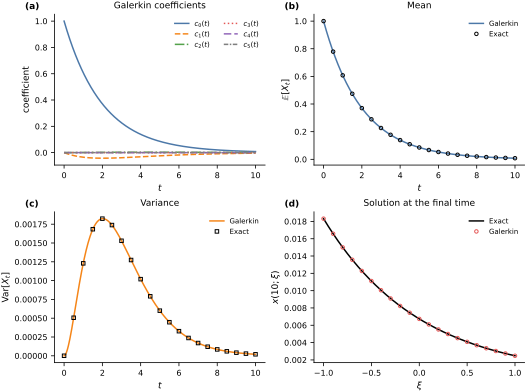

In [7]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=FIGURE_SIZES["full_tall"],
    constrained_layout=True,
)

colors = [
    BOOK_COLORS["blue"],
    BOOK_COLORS["orange"],
    BOOK_COLORS["green"],
    BOOK_COLORS["red"],
    BOOK_COLORS["purple"],
    BOOK_COLORS["gray"],
]
line_styles = ["-", "--", "-.", ":", (0, (5, 2)), (0, (3, 1, 1, 1))]

for index in range(degree + 1):
    axes[0, 0].plot(
        times_np,
        np.asarray(solution.ys[:, index]),
        color=colors[index],
        linestyle=line_styles[index],
        label=rf"$c_{index}(t)$",
    )
axes[0, 0].set(xlabel="$t$", ylabel="coefficient", title="Galerkin coefficients")
axes[0, 0].legend(ncol=2, loc="upper right")

axes[0, 1].plot(times_np, pc_mean, color=BOOK_COLORS["blue"], label="Galerkin")
axes[0, 1].plot(
    times_np[::20],
    exact_mean[::20],
    "o",
    color="black",
    markerfacecolor="none",
    label="Exact",
)
axes[0, 1].set(xlabel="$t$", ylabel=r"$\mathbb{E}[X_t]$", title="Mean")
axes[0, 1].legend()

axes[1, 0].plot(
    times_np,
    pc_variance,
    color=BOOK_COLORS["orange"],
    label="Galerkin",
)
axes[1, 0].plot(
    times_np[::20],
    exact_variance[::20],
    "s",
    color="black",
    markerfacecolor="none",
    label="Exact",
)
axes[1, 0].set(
    xlabel="$t$",
    ylabel=r"$\operatorname{Var}[X_t]$",
    title="Variance",
)
axes[1, 0].legend()

axes[1, 1].plot(
    test_inputs,
    exact_response[-1],
    color="black",
    label="Exact",
)
axes[1, 1].plot(
    test_inputs[::10],
    pc_response[-1, ::10],
    "o",
    color=BOOK_COLORS["red"],
    markerfacecolor="none",
    label="Galerkin",
)
axes[1, 1].set(
    xlabel=r"$\xi$",
    ylabel=r"$x(10;\xi)$",
    title="Solution at the final time",
)
axes[1, 1].legend()

finalize_axes(axes)
label_panels(axes)
plt.show()

The degree-five approximation reproduces the exact mean and variance throughout the time interval and provides an accurate parametric representation $\xi\mapsto x_p(t;\xi)$. The reported errors include polynomial truncation, quadrature discretization, and time-integration error.

## Exercise

Repeat the calculation for $p=0,1,\ldots,5$ and record the maximum mean, variance, and response errors over the displayed time interval. Then increase $\lambda_1$ from $0.1$ to $0.3$ and determine how the degree required for the same accuracy changes.

## Extension to multiple inputs

This section used one uncertain input and a scalar state. The next section constructs tensor-product polynomial bases for several independent inputs. The computational companion of the section on vector dynamical systems then combines those bases with vector-valued states.